In [1]:
import os, random, sys, warnings, copy
import numpy as np
from scipy.spatial import distance
import pandas as pd
import bct
from tqdm import tqdm

import neurogym as ngym
import torch
import torch.nn as nn
from src.neural_network import RNN, run_training, run_testing
from src.utils import normalize_x, fix_labels, get_weight_masks_schaefer, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12})
plt.rcParams["svg.fonttype"] = "none"
import seaborn as sns
from src.plotting import plot_activity, plot_iodata

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Device configuration

In [2]:
if sys.platform == 'linux':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif sys.platform == 'darwin':
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

mps


### Set params

In [3]:
# directories (ahmad: you will need to edit these!)
if sys.platform == 'linux':
    datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
    outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'
elif sys.platform == 'darwin':
    datadir = '/Users/lindenmp/Google-Drive-Rutgers/work/research_projects/neuro_rnn/data'
    outdir = '/Users/lindenmp/Google-Drive-Rutgers/work/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'  # options: ['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']
dt = 100  # don't change
batch_size = 16 # tweak as much as you like!
decision = 300 # options: [100, 200, 300, 400]
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 3  # feel free to modify the integer multiplier here (i.e., the 5).

# RNN model and training parameters
rnn_model = 'rnn-tanh'  # options: ['rnn-tanh', 'rnn-relu', 'lstm', 'gru']
hidden_size = 50  # options: [50, 100, 200]
n_epochs = 2000  # options: any integer value
lr = 0.001  # can change, but wouldn't bother right noe

# regularization parameters
kernel_type = None  # options: ['sa_axis', 'euclidean', None]
reg_type = 'l2'  # options: ['l1', 'l2']
reg_weight = 0.0001  # options: [0.0001, 0.001, 0.002]
mask_weights = False  # options: [True, False]

In [4]:
if task == 'ContextDecisionMaking-v0':
    timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
else:
    timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': 1, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'kernel_type': kernel_type, 'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs
}

### Environment: make dataset

3 3
(72, 16, 3) (72, 16)


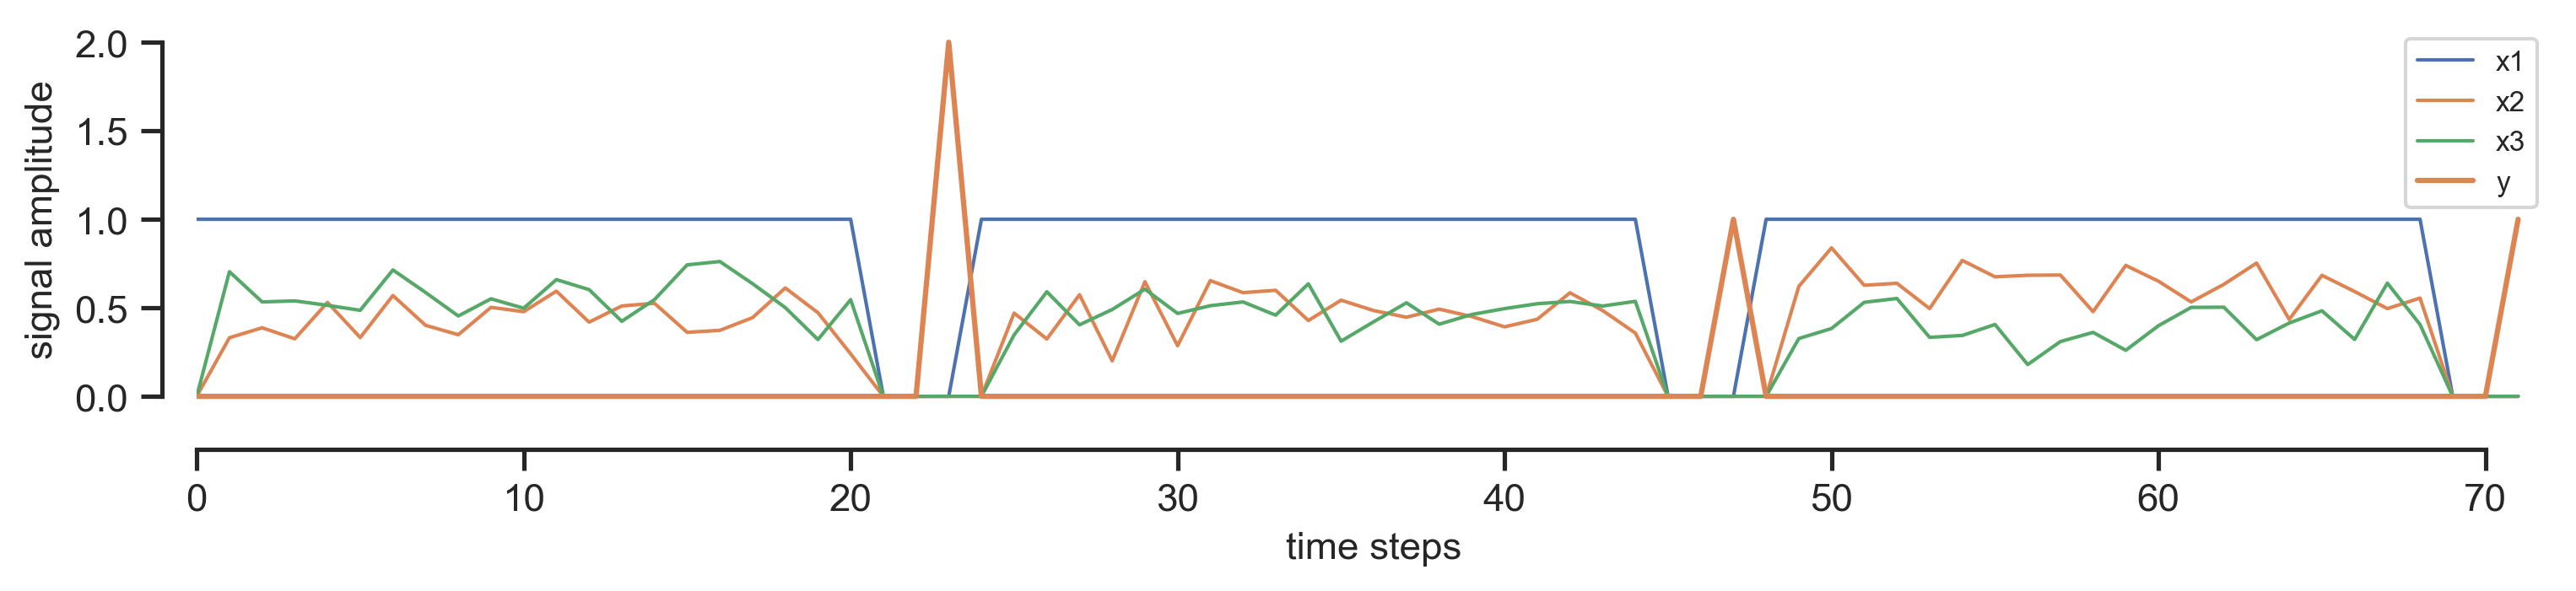

In [5]:
dataset = ngym.Dataset(config['task'], env_kwargs=env_kwargs, batch_size=config['batch_size'], seq_len=config['seq_len'])
input_size = dataset.env.observation_space.shape[0]
num_classes = dataset.env.action_space.n
print(input_size, num_classes)

# plot
inputs, labels = dataset()
trim = int((decision - 100) / dt)
labels = fix_labels(labels, decision=int(decision / dt), trim=trim)
print(inputs.shape, labels.shape)

# plot input/output (x/y) data
plot_iodata(
    inputs[:, 0, :], labels[:, 0],
    rc_params={'figure.dpi': 300, 'savefig.dpi': 300},
    show=True, ax_params={'xlim': [0, seq_len]}
)

### Setup weight masks

In [6]:
# weight masks
centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
centroids = centroids[:hidden_size]
roi_names = list(centroids['ROI Name'])
input_system = 'Vis'
output_system = 'Default'
masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)

if mask_weights:
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io
print(n_io)

na


### Plot weight masks

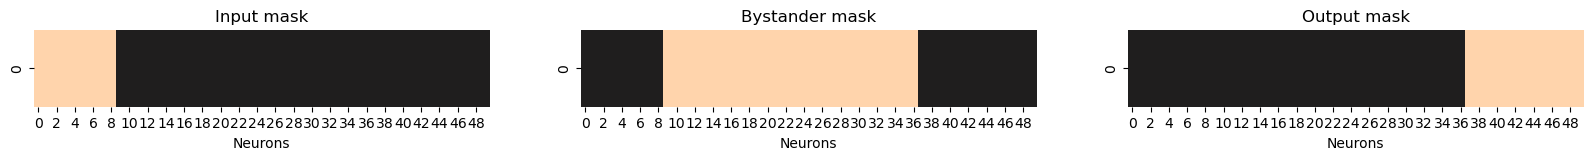

In [7]:
f, ax = plt.subplots(1, 3, figsize=(20, 1))
sns.heatmap(masks['input_weight_mask'][np.newaxis], ax=ax[0], square=False, center=0, cbar=False)
ax[0].set_title('Input mask')
ax[0].set_xlabel('Neurons')
sns.heatmap(masks['bystanders'][np.newaxis], ax=ax[1], square=False, center=0, cbar=False)
ax[1].set_title('Bystander mask')
ax[1].set_xlabel('Neurons')
sns.heatmap(masks['output_weight_mask'][np.newaxis], ax=ax[2], square=False, center=0, cbar=False)
ax[2].set_title('Output mask')
ax[2].set_xlabel('Neurons')
plt.show()

In [8]:
mask_labels = ['input_input', 'bystanders_bystanders', 'output_output',
               'input_output', 'output_input',
               'input_bystanders', 'bystanders_input',
               'output_bystanders', 'bystanders_output']
n_masks = len(mask_labels)

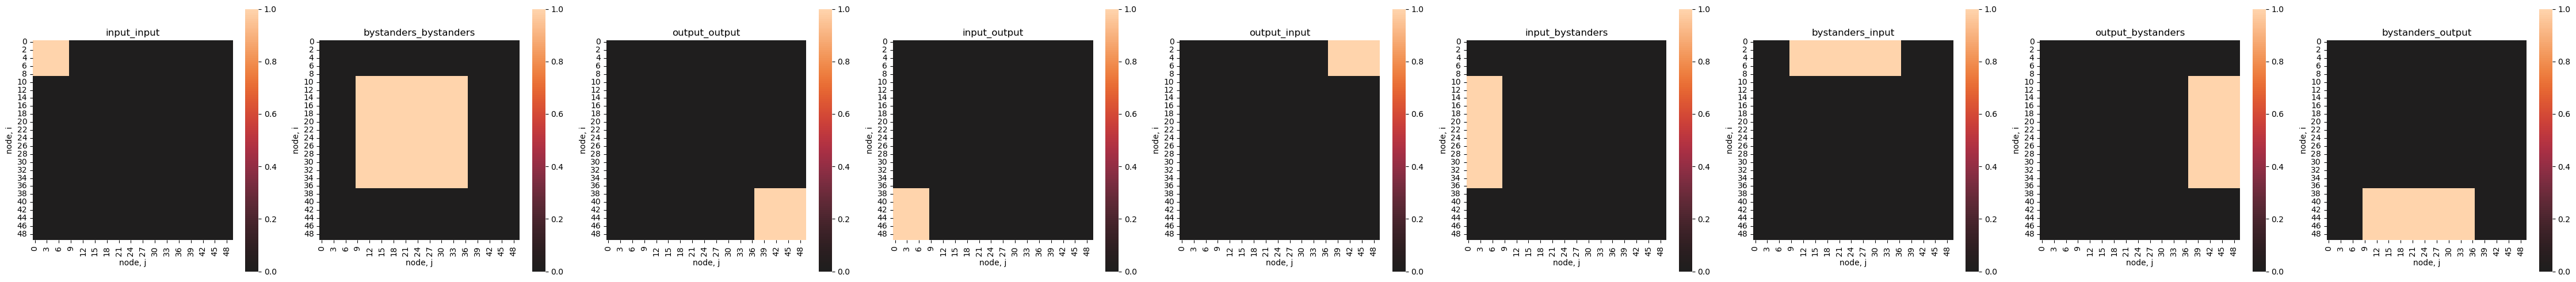

In [9]:
f, ax = plt.subplots(1, n_masks, figsize=(n_masks*5, 5))
for i, mask in enumerate(mask_labels):
    sns.heatmap(masks[mask], ax=ax[i], square=True, center=0)
    ax[i].set_title(mask)
    ax[i].set_xlabel('node, j')
    ax[i].set_ylabel('node, i')
f.tight_layout()
plt.show()

### Setup regularization kernel (for spatial embedding)

In [10]:
if kernel_type is None:
    # no distance penalty
    regularization_kernel = None
elif kernel_type == 'euclidean':
    # static distance matrix for regularization
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    if sys.platform == 'darwin':
        centroids.drop(columns='ROI Label', inplace=True)
    centroids = centroids[:hidden_size]
    centroids.set_index("ROI Name", inplace=True)
    distance_matrix = distance.pdist(centroids, "euclidean")  # get euclidean distances between nodes
    distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix
    regularization_kernel = normalize_x(distance_matrix)
elif kernel_type == 'sa_axis':
    sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(hidden_size * 2)))
    sa_axis = sa_axis[:hidden_size]
    n = len(sa_axis)
    distance_matrix = np.zeros((n, n))
    for i in np.arange(n):
        for j in np.arange(n):
            distance_matrix[i, j] = sa_axis[i] - sa_axis[j]
    distance_matrix = np.abs(distance_matrix)
    regularization_kernel = normalize_x(distance_matrix)

# plot
if regularization_kernel is None:
    pass
elif regularization_kernel.ndim == 2:
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.heatmap(regularization_kernel, ax=ax, square=True, cmap='coolwarm', center=0)
    plt.show()
elif regularization_kernel.ndim == 3:
    f, ax = plt.subplots(1, 4, figsize=(20, 5))
    sns.heatmap(regularization_kernel[:, :, 0], ax=ax[0], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[0].set_title('Epoch 0')
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.33)], ax=ax[1], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[1].set_title('Epoch {0}'.format(int(n_epochs*.33)))
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.66)], ax=ax[2], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[2].set_title('Epoch {0}'.format(int(n_epochs*.66)))
    sns.heatmap(regularization_kernel[:, :, -1], ax=ax[3], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[3].set_title('Epoch {0}'.format(int(n_epochs)))
plt.show()

### Train model

In [11]:
run = 0
random.seed(run)
np.random.seed(run)
torch.manual_seed(run)
torch.cuda.manual_seed(run)
torch.cuda.manual_seed_all(run)

In [12]:
# setup weight masks
if mask_weights:
    input_weight_mask = masks['input_weight_mask']
    output_weight_mask = masks['output_weight_mask']
else:
    input_weight_mask = None
    output_weight_mask = None
    print(input_weight_mask, output_weight_mask)

None None


In [13]:
# initialize the model
model = RNN(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes, type=rnn_model,
            regularization_kernel=regularization_kernel,
            input_weight_mask=input_weight_mask, output_weight_mask=output_weight_mask).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = None
tra_loss, val_loss, tes_acc = run_training(dataset=dataset, model=model, optimizer=optimizer, criterion=criterion, config=config, scheduler=scheduler, return_models=False)

epoch 100 | running training loss: 0.27830 | running validation loss: 0.26829 | test accuracy: 0.00%
epoch 200 | running training loss: 0.10696 | running validation loss: 0.10363 | test accuracy: 47.00%
epoch 300 | running training loss: 0.04987 | running validation loss: 0.04730 | test accuracy: 47.00%
epoch 400 | running training loss: 0.03866 | running validation loss: 0.03590 | test accuracy: 47.00%
epoch 500 | running training loss: 0.03558 | running validation loss: 0.03271 | test accuracy: 47.00%
epoch 600 | running training loss: 0.03431 | running validation loss: 0.03131 | test accuracy: 47.00%
epoch 700 | running training loss: 0.03359 | running validation loss: 0.03068 | test accuracy: 67.00%
epoch 800 | running training loss: 0.03311 | running validation loss: 0.03007 | test accuracy: 71.00%
epoch 900 | running training loss: 0.03238 | running validation loss: 0.02953 | test accuracy: 72.00%
epoch 1000 | running training loss: 0.03595 | running validation loss: 0.03242 | te

### Test model

In [14]:
n_trials = 100
model.eval()
accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(dataset=dataset, model=model, n_trials=n_trials)

Average accuracy across 100 trials: 84.00%


In [15]:
print(inputs.shape)
print(labels.shape)
print(hidden_activity.shape)
print(output_activity.shape)

(100, 24, 3)
(100, 24)
(100, 24, 50)
(100, 24, 3)


# Plot

### Plot activity


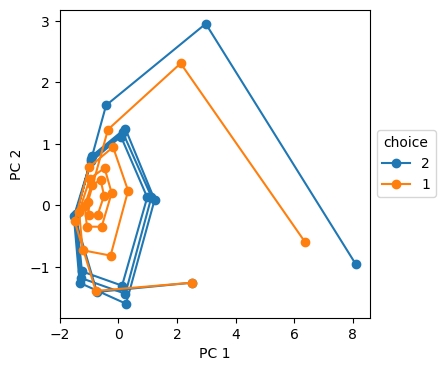

In [16]:
run_pca=True
plot_activity(hidden_activity, info, config, run_pca=run_pca)

### Plot training curves and weights

In [17]:
file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-72-300_model-rnn-tanh-50-16-0.001-1-2000_wmask-False-na_reg-l2-0.0001-None


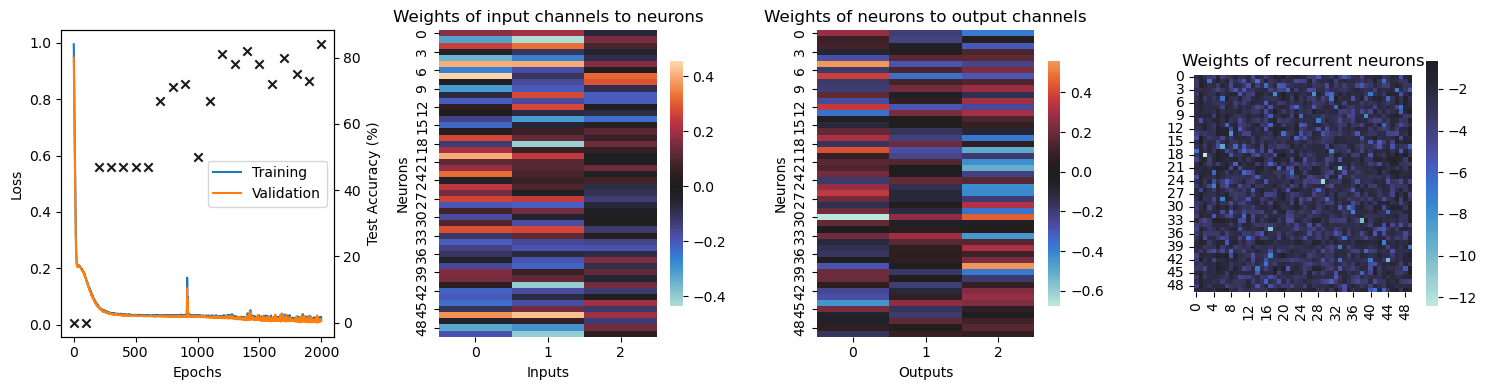

In [18]:
f, ax = plt.subplots(1, 4, figsize=(15, 4))

# performance
sns.lineplot(tra_loss, ax=ax[0], label='Training')
sns.lineplot(val_loss, ax=ax[0], label='Validation')
ax[0].set_ylabel('Loss')
ax0_twin = ax[0].twinx()
ax0_twin.scatter(np.arange(0, n_epochs+100, 100), tes_acc*100, marker='x', c='k')
ax0_twin.set_ylabel('Test Accuracy (%)')
ax[0].set_xlabel('Epochs')
ax[0].legend(loc='center right')

# input weights
sns.heatmap(model.rnn.weight_ih_l0.detach().cpu().numpy(), ax=ax[1], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[1].set_title('Weights of input channels to neurons')
ax[1].set_xlabel('Inputs')
ax[1].set_ylabel('Neurons')

# output weights
sns.heatmap(model.fc.weight.detach().cpu().numpy().T, ax=ax[2], square=False, center=0, cbar_kws={"shrink": 0.80})
ax[2].set_title('Weights of neurons to output channels')
ax[2].set_xlabel('Outputs')
ax[2].set_ylabel('Neurons')

# hidden weights
h_weights = model.rnn.weight_hh_l0.detach().cpu().numpy()
sns.heatmap(np.log(np.abs(h_weights)), ax=ax[3], square=True, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[3].set_title('Weights of recurrent neurons')

f.tight_layout()
plt.show()
f.savefig(os.path.join(outdir, '{0}_single-run.png'.format(file_str)), dpi=300, bbox_inches='tight', pad_inches=0.01)